# Exploratory Data Analysis: K-MNIST

We will verify the structural integrity of the Kuzushiji-MNIST (K-MNIST) dataset and get comfortable with it. 

The purpose of this exploratory analysis is to:
1. Verify the dimensionality and spatial boundaries of the tensors.
2. Prove the uniform distribution of classes to justify the use of standard Accuracy as our primary evaluation metric.
3. Visually confirm the dataset composition to establish a baseline for our Convolutional and Multi-Layer Perceptron architectures.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Configure matplotlib styling
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'serif'

print("Dependencies loaded successfully.")

## 1. Dataset Composition and Dimensionality

We begin by loading the raw `.npz` arrays from the local dependencies. We must verify that the training set contains exactly 60,000 samples and the testing set contains 10,000 samples, with a spatial resolution of $28 \times 28$ pixels. 

Furthermore, we will inspect the pixel intensity boundaries to mathematically justify our decision to scale the input features by dividing by 255 in our PyTorch `DataModule`.

In [6]:
# Define the relative path to the raw data
data_dir = '../datasets/KMNIST/raw/'

# Load the arrays into memory
X_train = np.load(os.path.join(data_dir, 'kmnist-train-imgs.npz'))['arr_0']
y_train = np.load(os.path.join(data_dir, 'kmnist-train-labels.npz'))['arr_0']
X_test = np.load(os.path.join(data_dir, 'kmnist-test-imgs.npz'))['arr_0']
y_test = np.load(os.path.join(data_dir, 'kmnist-test-labels.npz'))['arr_0']

# Verify Dimensionality
print("=== Tensor Dimensionality ===")
print(f"Training Data:   {X_train.shape} | Labels: {y_train.shape}")
print(f"Testing Data:    {X_test.shape}  | Labels: {y_test.shape}")

# Verify Feature Boundaries
pixel_min = X_train.min()
pixel_max = X_train.max()
print("\n=== Feature Boundaries ===")
print(f"Minimum Pixel Intensity: {pixel_min}")
print(f"Maximum Pixel Intensity: {pixel_max}")

=== Tensor Dimensionality ===
Training Data:   (60000, 28, 28) | Labels: (60000,)
Testing Data:    (10000, 28, 28)  | Labels: (10000,)

=== Feature Boundaries ===
Minimum Pixel Intensity: 0
Maximum Pixel Intensity: 255


## 2. Class Balance and Metric Justification

In machine learning optimization, the choice of the objective metric (e.g., Accuracy vs. F1-Score) is dictated by the distribution of the target labels. If a dataset is imbalanced, a model can achieve deceptively high accuracy by simply predicting the majority class. 

Here, we compute the frequency of each class label in the training set to prove uniformity.

=== Class Distribution ===
Class 0: 6000 samples
Class 1: 6000 samples
Class 2: 6000 samples
Class 3: 6000 samples
Class 4: 6000 samples
Class 5: 6000 samples
Class 6: 6000 samples
Class 7: 6000 samples
Class 8: 6000 samples
Class 9: 6000 samples

Standard Deviation of Class Counts: 0.00


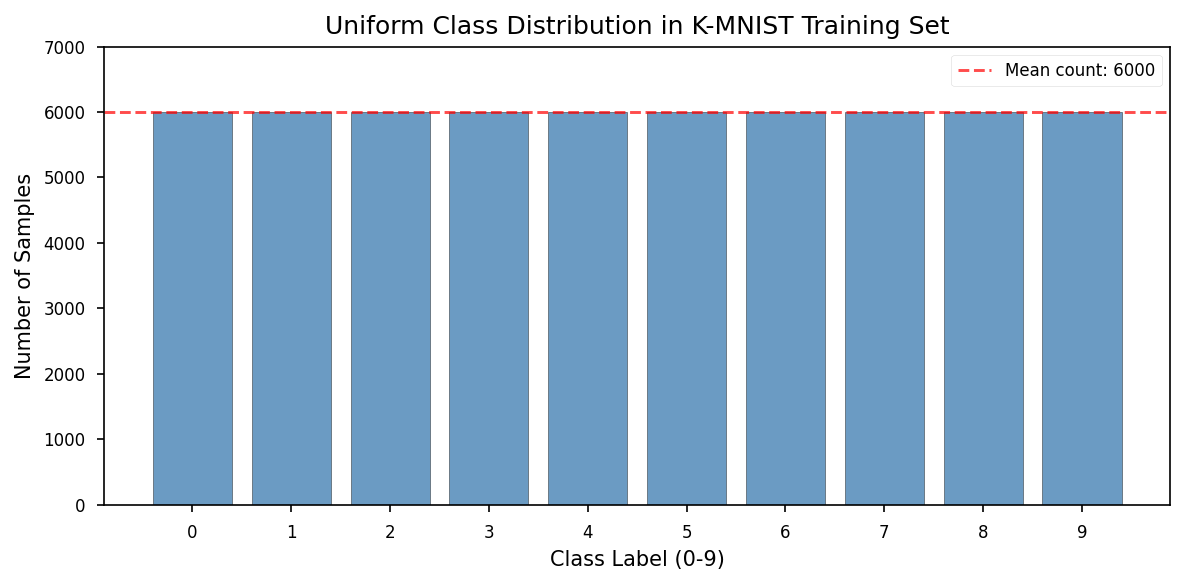

In [7]:
# Calculate the frequency of each class in the training set
classes, counts = np.unique(y_train, return_counts=True)

print("=== Class Distribution ===")
for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count} samples")

std_dev = np.std(counts)
print(f"\nStandard Deviation of Class Counts: {std_dev:.2f}")

# Visualize the distribution
plt.figure(figsize=(8, 4))
bars = plt.bar(classes, counts, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Uniform Class Distribution in K-MNIST Training Set', fontsize=12)
plt.xlabel('Class Label (0-9)', fontsize=10)
plt.ylabel('Number of Samples', fontsize=10)
plt.xticks(classes)

# Add a horizontal line to represent the mean
plt.axhline(y=np.mean(counts), color='red', linestyle='--', alpha=0.7, label=f'Mean count: {int(np.mean(counts))}')
plt.legend()
plt.ylim(0, 7000)

plt.tight_layout()
plt.show()

**Conclusion on Class Balance:**
The standard deviation of the class counts is exactly 0.00, proving that the dataset follows a perfectly uniform discrete distribution ($n=6000$ per class). Therefore, we can mathematically guarantee that **Validation Accuracy** is a robust, unbiased metric for evaluating our neural network architectures during the Hyperparameter Optimization search.

## 3. Visual Verification

Finally, we render a sample from each class. While the K-MNIST images share the same $28 \times 28$ grayscale structure as traditional MNIST, they represent cursive *Hentaigana* characters. Visualizing these samples confirms the data was decoded correctly and provides a reference for the structural complexity the Convolutional Neural Network will be tasked with feature-mapping.

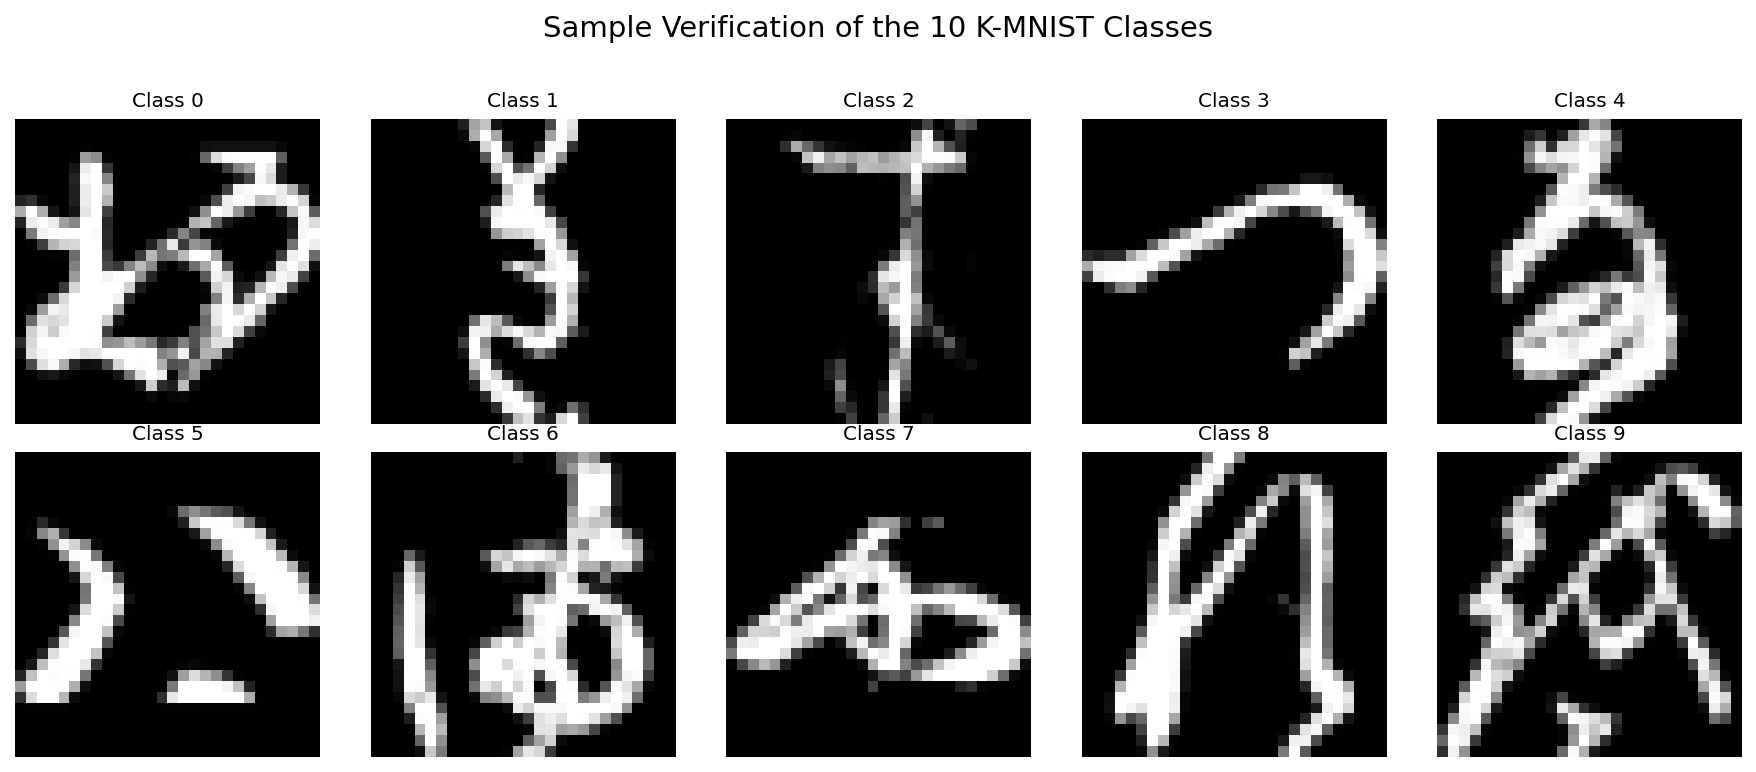

In [9]:
# Create a 2x5 grid of subplots
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Verification of the 10 K-MNIST Classes', fontsize=14, y=1.02)

# Extract and plot the first instance of each class
for class_idx in range(10):
    # Find the index of the first image with this label
    first_occurrence_idx = np.where(y_train == class_idx)[0][0]
    img = X_train[first_occurrence_idx]
    
    # Determine subplot row and column
    row = class_idx // 5
    col = class_idx % 5
    
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f'Class {class_idx}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 4. Transition to Benchmarking

Having verified the integrity, bounds, and balance of the K-MNIST dataset, the data is formally cleared for model ingestion. 

The next step in the methodology is to establish the performance baselines. By executing `benchmark.py`, we will train an untuned Convolutional Neural Network (CNN) and a Multi-Layer Perceptron (MLP) on this dataset. The resulting baseline accuracy will serve as the "control group" to measure the effectiveness of the Random Search, Grid Search, Successive Halving, and Genetic Algorithms implemented in our engine.
